In [1]:
## Load the necessary libraries
import pickle
from utils.Train import HANNA
from utils.Utils import predict, create_embedding_matrix
from utils.Plots import plot_ln_gamma
from utils.Utils import initiliaze_ChemBERTA
import torch
import numpy as np

In [2]:
# Paths for model and scaler
model_path = f'Model/HANNA_Val.pt'
scaler_path = f'Model/scalerHANNA_Val.pkl'
# Load the model
device = torch.device("mps" if torch.cuda.is_available() else "cpu")
model = HANNA().to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
# Set the model to evaluation mode
model.eval()
# Load the scaler
with open(scaler_path, 'rb') as f:
    scaler = pickle.load(f)

/opt/homebrew/Caskroom/miniforge/base/envs/train_hanna/lib/python3.12/site-packages/sklearn/base.py:463: InconsistentVersionWarning: Trying to unpickle estimator StandardScaler from version 1.3.0 when using version 1.8.0. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [3]:
# Initialize ChemBERTa
ChemBERTA, tokenizer = initiliaze_ChemBERTA(model_name="DeepChem/ChemBERTa-77M-MTR", device=None)

Loading weights:   0%|          | 0/53 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: DeepChem/ChemBERTa-77M-MTR
Key                        | Status     | 
---------------------------+------------+-
regression.out_proj.bias   | UNEXPECTED | 
norm_mean                  | UNEXPECTED | 
regression.dense.bias      | UNEXPECTED | 
norm_std                   | UNEXPECTED | 
regression.dense.weight    | UNEXPECTED | 
regression.out_proj.weight | UNEXPECTED | 
pooler.dense.bias          | MISSING    | 
pooler.dense.weight        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


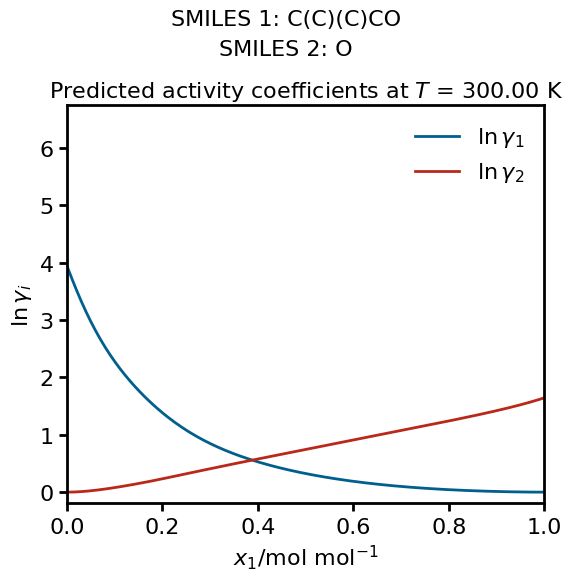

('Output/System_C(C)(C)CO_AND_O_AT_300.00K.png',
 'Output/System_C(C)(C)CO_O_300.00K.csv')

In [4]:
# Example usage with tert-butanol and water at 300 K:
SMILES_1 = "C(C)(C)CO" # SMILES of component 1
SMILES_2 = "O" # SMILES of component 2
T = 300 # Temperature in K
x1_values = np.linspace(0, 1, 200) # Vector of mole fractions of component 1
embedding_matrix =create_embedding_matrix(SMILES_1, SMILES_2, T, device, ChemBERTA, tokenizer, x1_values) # Create the embedding matrix
x_pred, ln_gammas_pred = predict(embedding_matrix, scaler, model, device) # Predict the logarithmic activity coefficients
plot_ln_gamma(x_pred, ln_gammas_pred, T, SMILES_1, SMILES_2) # Plot the logarithmic activity coefficients
# NOTE: The warning "Some weights of RobertaModel were not initialized from the model checkpoint..." is expected and can be ignored, because we are not using the pooler head of the model.